In [3]:
import pandas as pd
import numpy as np 
train_data=pd.read_csv("../data/processed/train.csv")

In [4]:
test_data=pd.read_csv("../data/processed/test.csv")

In [5]:
train_data.shape

(8000, 23)

In [6]:
train_data

,category,region,order_value,payment_method,is_cod,discount_pct,is_high_discount,expected_delivery_days,delivery_days,delivery_delay,...,customer_return_rate,is_high_value,returned,order_dayofweek,is_weekend,order_month,time_since_last_order,discount_amount,net_order_value,delivery_delay_ratio
0,Fashion,North,2884.18,Wallet,0,36.9,0,5,7,2,...,0.000,1,1,6,1,5,50.0,1064.26242,1819.91758,1.400000
1,Electronics,Central,23277.65,COD,1,22.5,0,4,5,1,...,0.000,1,0,3,0,3,NaN,5237.47125,18040.17875,1.250000
2,Mobiles,West,31650.53,Wallet,0,26.3,0,4,6,2,...,0.250,0,0,1,0,7,89.0,8324.08939,23326.44061,1.500000
3,Electronics,East,11301.98,COD,1,12.4,0,4,7,3,...,0.000,0,1,1,0,6,39.0,1401.44552,9900.53448,1.750000
4,Furniture,East,24736.17,Card,0,11.1,0,4,5,1,...,0.000,0,0,0,0,5,12.0,2745.71487,21990.45513,1.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,Fashion,North,1577.81,COD,1,8.7,0,4,4,0,...,0.000,0,0,6,1,6,3.0,137.26947,1440.54053,1.000000
7996,Footwear,Central,2494.14,Card,0,8.1,0,4,7,3,...,0.333,0,0,3,0,5,55.0,202.02534,2292.11466,1.750000
7997,Mobiles,North,45096.59,NetBanking,0,12.8,0,4,2,0,...,0.000,1,0,5,1,5,81.0,5772.36352,39324.22648,0.500000
7998,Sports,East,5585.83,COD,1,22.6,0,5,5,0,...,0.000,1,1,6,1,7,54.0,1262.39758,4323.43242,1.000000


In [7]:
numeric_cols=train_data.select_dtypes(include=['int64','float64'])
binary_cols = [col for col in numeric_cols if train_data[col].nunique() == 2]
Numeric_cols = [col for col in numeric_cols if col not in binary_cols]
c=train_data.select_dtypes(include=['object'])

In [8]:
n=train_data[Numeric_cols]

In [9]:
b=train_data[binary_cols]

### Varience threshould

In [10]:
from sklearn.feature_selection import VarianceThreshold
v=VarianceThreshold(threshold=0)


In [11]:
n.var().sort_values()

customer_return_rate         8.442965e-02
delivery_delay_ratio         3.103840e-01
customer_previous_returns    7.350794e-01
expected_delivery_days       7.843478e-01
delivery_delay               1.840525e+00
order_month                  2.987126e+00
customer_previous_orders     3.433035e+00
order_dayofweek              4.019090e+00
delivery_days                4.311685e+00
discount_pct                 1.174877e+02
time_since_last_order        8.277741e+02
discount_amount              6.734232e+06
net_order_value              1.161225e+08
order_value                  1.589322e+08
dtype: float64

#### There is no need to apply the varience there is no constant feature

#### correlation 

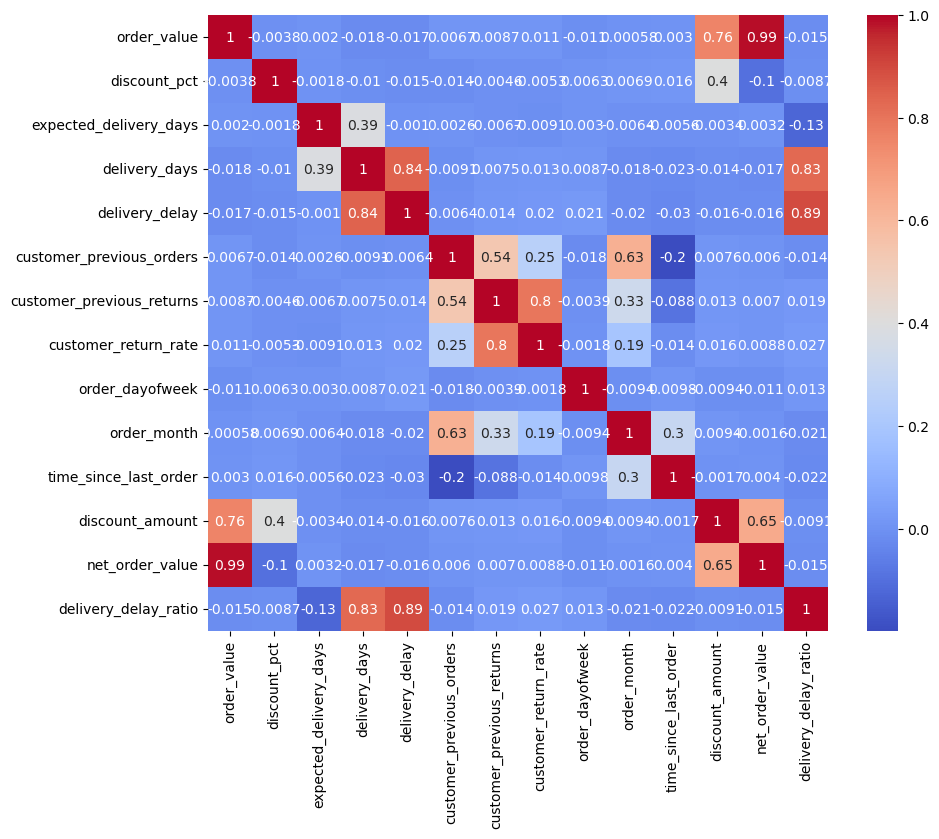

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = n.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [13]:

n.drop(columns=['net_order_value'],axis=1,inplace=True)

C:\Users\dnyan\AppData\Local\Temp\ipykernel_20776\3031960564.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  n.drop(columns=['net_order_value'],axis=1,inplace=True)


#### 99 correlated feature are droped 

## Mutual info

In [14]:
from sklearn.feature_selection import mutual_info_classif

In [15]:
y=b['returned']

In [16]:
n=n.copy()

In [17]:
n=n.fillna(n.median())

In [18]:
mi_scores = mutual_info_classif(
    n,
    y,
    random_state=42
)

In [19]:
mi_scores

array([0.0032795 , 0.00777053, 0.00364315, 0.        , 0.00136775,
       0.00283299, 0.01692775, 0.02206172, 0.        , 0.00202678,
       0.00385483, 0.        , 0.00243752])

In [20]:
mi_num = pd.DataFrame({
    "feature": n.columns,
    "mi_score": mi_scores
}).sort_values(
    "mi_score",
    ascending=False
)

In [21]:
mi_num

,feature,mi_score
7,customer_return_rate,0.022062
6,customer_previous_returns,0.016928
1,discount_pct,0.007771
10,time_since_last_order,0.003855
2,expected_delivery_days,0.003643
0,order_value,0.003279
5,customer_previous_orders,0.002833
12,delivery_delay_ratio,0.002438
9,order_month,0.002027
4,delivery_delay,0.001368


In [22]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)



In [23]:
model.fit(n, y)



RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [25]:
importance_df = pd.DataFrame({
    "feature": n.columns,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

In [26]:
importance_df

,feature,importance
0,order_value,0.167244
11,discount_amount,0.141893
1,discount_pct,0.134728
10,time_since_last_order,0.110005
8,order_dayofweek,0.074078
9,order_month,0.064125
12,delivery_delay_ratio,0.063248
5,customer_previous_orders,0.053090
7,customer_return_rate,0.051982
3,delivery_days,0.047810


In [27]:
c=c.copy()

In [30]:
c=pd.get_dummies(c, drop_first=True).astype(int)

In [32]:
model.fit(c,y)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [34]:
importance_df = pd.DataFrame({
    "feature": c.columns,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

In [35]:
importance_df

,feature,importance
2,category_Fashion,0.199030
3,category_Footwear,0.165060
0,category_Books,0.080657
15,payment_method_UPI,0.059874
14,payment_method_NetBanking,0.051642
13,payment_method_Card,0.051533
9,region_East,0.048216
12,region_West,0.047561
10,region_North,0.044771
11,region_South,0.044144


In [40]:
b=b.drop(columns=['returned'],axis=1)
model.fit(b,y)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [41]:
importance_df = pd.DataFrame({
    "feature": b.columns,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

In [42]:
importance_df

,feature,importance
2,is_delivery_delayed,0.429234
0,is_cod,0.389794
1,is_high_discount,0.066328
4,is_weekend,0.061243
3,is_high_value,0.053401


In [43]:
df=pd.concat([b,c,n],axis=1)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   is_cod                     8000 non-null   int64  
 1   is_high_discount           8000 non-null   int64  
 2   is_delivery_delayed        8000 non-null   int64  
 3   is_high_value              8000 non-null   int64  
 4   is_weekend                 8000 non-null   int64  
 5   category_Books             8000 non-null   int64  
 6   category_Electronics       8000 non-null   int64  
 7   category_Fashion           8000 non-null   int64  
 8   category_Footwear          8000 non-null   int64  
 9   category_Furniture         8000 non-null   int64  
 10  category_Home & Kitchen    8000 non-null   int64  
 11  category_Mobiles           8000 non-null   int64  
 12  category_Sports            8000 non-null   int64  
 13  category_Toys              8000 non-null   int64

In [46]:
model.fit(df,y)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [47]:
importance_df = pd.DataFrame({
    "feature": df.columns,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

In [48]:
importance_df

,feature,importance
22,order_value,0.100024
33,discount_amount,0.092451
23,discount_pct,0.089737
32,time_since_last_order,0.075081
34,delivery_delay_ratio,0.054635
30,order_dayofweek,0.051120
29,customer_return_rate,0.049399
31,order_month,0.048354
27,customer_previous_orders,0.044087
25,delivery_days,0.042485


In [49]:
model.score(df,y)

1.0

In [60]:
x_test = test_data.drop(columns=['returned','net_order_value'])
y_test = test_data['returned']

cols = x_test.select_dtypes(include=['object']).columns

x_test = pd.get_dummies(
    x_test,
    columns=cols,
    drop_first=True,
    dtype=int
)
x_test = x_test.reindex(columns=df.columns, fill_value=0)
x_test = x_test.fillna(0)

In [61]:
from sklearn.metrics import classification_report
print(classification_report(y_test,model.predict(x_test)))

              precision    recall  f1-score   support

           0       0.79      0.97      0.87      1542
           1       0.59      0.14      0.23       458

    accuracy                           0.78      2000
   macro avg       0.69      0.56      0.55      2000
weighted avg       0.74      0.78      0.72      2000



In [63]:
df=df.drop(columns=[
    "delivery_days",
    "delivery_delay",
    "customer_previous_returns",
    "is_delivery_delayed",
    "is_high_discount"
],axis=1)

In [64]:
x_test=x_test.drop(columns=[
    "delivery_days",
    "delivery_delay",
    "customer_previous_returns",
    "is_delivery_delayed",
    "is_high_discount"
],axis=1)